In [1]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
parent_dir = os.path.dirname(os.environ["GTE_DIR"].replace("Glaciation_time_estimator",""))
GTE_DIR=os.environ["GTE_DIR"]
sys.path.insert(0, parent_dir)
from glaciation_time_estimator.data_postprocessing.Job_result_fp_generator import generate_tracking_filenames
from glaciation_time_estimator.auxiliary_func.config_reader import read_config
from glaciation_time_estimator.auxiliary_func.chunking_data import ChunkLoader

In [2]:
config = read_config(
    os.path.join(GTE_DIR,'config.yaml'))
analyze_year=True
years=[2007,2008,2009,2010,2011]
glac_threshold=0.4
global global_rmse
global_rmse = config["Global_sqrt_mse"]
classifiacation_palette = ['#e41a1c', '#377eb8', "#4daf4a"]
# temperature_palette = ['#eff3ff','#c6dbef','#9ecae1','#6baed6','#3182bd','#08519c']
temperature_palette = ['#f1eef6','#d0d1e6','#a6bddb','#74a9cf','#2b8cbe','#045a8d']
classifiacation_palette = ['#e41a1c', '#377eb8', "#4daf4a"]
temperature_palette = ['#eff3ff','#c6dbef','#9ecae1','#6baed6','#3182bd','#08519c']


In [6]:
dataset = ChunkLoader(years,config=config)

In [23]:
def calculate_temp_occurance_rate(dfs):
    combined_cloud_df , _ , glaciating_clouds = dfs
    return glacidataset.cloud_chunk.groupby("min_temp")["is_glaciating"].mean()*100
def calculate_pole_temp_occurance_rate(dfs):
    cloud_chunk , _ , _ = dfs
    return pd.pivot_table(cloud_chunk,values='is_glaciating' ,index=["Hemisphere"], columns=["min_temp"], aggfunc='mean')

In [18]:
occurance_rate_with_temp = dataset.execute_analysis(calculate_temp_occurance_rate)
occurance_rate_with_temp = pd.concat(
    {year: s for year, s in zip(years, occurance_rate_with_temp)},
    axis=1
)

[2007, 2008, 2009, 2010, 2011]


In [24]:
pole_temp_occurance_rate = dataset.execute_analysis(calculate_pole_temp_occurance_rate)

[2007, 2008, 2009, 2010, 2011]


In [29]:
# 1. Wide format (year as outer column level):
wide = pd.concat(
    {year: pt for year, pt in zip(years, pole_temp_occurance_rate)},
    axis=1
)
# name the column levels for clarity:
wide.columns.names = ['year', 'min_temp']
wide.index.name = 'Hemisphere'

# now `wide` looks like:
#               2007                                     2008          …
# min_temp       -36      -30   …    -6      2009       -36      -30  …   -6  
# Hemisphere
# North       0.099024  0.072207 …  0.0  0.095284  0.074029 …  0.0  …
# South       0.107854  0.054272 …  0.0  0.108102  0.053574 …  0.0  …

# 2. Long format (one row per hemisphere × min_temp × year):
pole_temp_occurance_rate_combined = pd.concat(
    [
        pt.reset_index()               # Hemisphere becomes a column
          .melt(id_vars='Hemisphere',  # unpivot the min_temp columns
                var_name='min_temp',
                value_name='Occurance rate')
          .assign(year=year)           # add the year column
        for pt, year in zip(pole_temp_occurance_rate, years)
    ],
    ignore_index=True
)

In [39]:
pole_temp_occurance_rate_combined.to_csv("/cluster/work/climate/dnikolo/n2o/Glaciation_time_estimator/Result_analysis/Multiyear_analysis/pole_temp_occurance_rate.csv")
occurance_rate_with_temp.to_csv("/cluster/work/climate/dnikolo/n2o/Glaciation_time_estimator/Result_analysis/Multiyear_analysis/temp_occurance_rate.csv")

In [3]:
pole_temp_occurance_rate_combined =pd.read_csv("/cluster/work/climate/dnikolo/n2o/Glaciation_time_estimator/Result_analysis/Multiyear_analysis/pole_temp_occurance_rate.csv")
occurance_rate_with_temp = pd.read_csv("/cluster/work/climate/dnikolo/n2o/Glaciation_time_estimator/Result_analysis/Multiyear_analysis/temp_occurance_rate.csv")

In [4]:
result_std = pole_temp_occurance_rate_combined.groupby(['min_temp',"Hemisphere"])['Occurance rate'].std()
result_mean = pole_temp_occurance_rate_combined.groupby(['min_temp',"Hemisphere"])['Occurance rate'].mean()

NameError: name 'classification_palette' is not defined

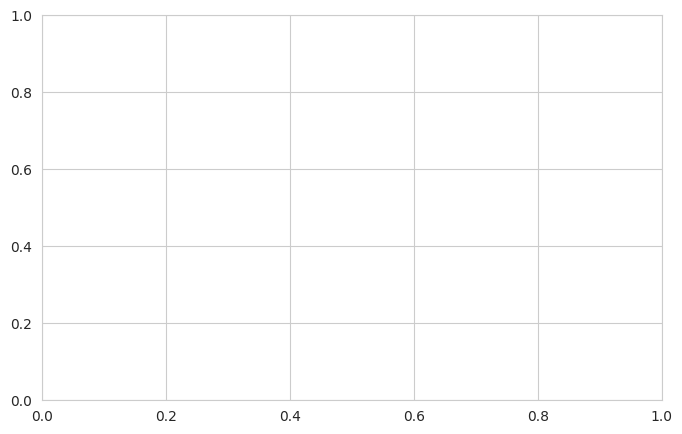

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare DataFrame
df_mean = result_mean.reset_index().rename(columns={'Occurance rate': 'mean'})
df_std  = result_std .reset_index().rename(columns={'Occurance rate': 'std'})
df = pd.merge(df_mean, df_std, on=['min_temp', 'Hemisphere'])

# Compute range strings and midpoints
df['range_str'] = df['min_temp'].apply(lambda t: f"{t} to {t+6} °C")
df['midpoint']  = df['min_temp'] + 3  # midpoint of each 6° bin

# Establish the categorical ordering of ranges
order = (
    df[['midpoint', 'range_str']]
      .drop_duplicates()
      .sort_values('midpoint')         # from coldest (smallest min_temp) to warmest
)
midpoints = order['midpoint'].tolist()
labels     = order['range_str'].tolist()

# Plot
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
ax = plt.gca()
i=0
for hemisphere, grp in df.groupby('Hemisphere'):
    grp = grp.sort_values('midpoint')
    ax.plot(grp['midpoint'], grp['mean'], marker='o', label=hemisphere,color=classification_palette[i])
    ax.fill_between(
        grp['midpoint'],
        grp['mean'] - grp['std'],
        grp['mean'] + grp['std'],
        color=classification_palette[i],
        alpha=0.3
    )
    i+=1


# Tick at each midpoint, labeled by the range
ax.set_xticks(midpoints)
ax.set_xticklabels(labels, rotation=45, ha='right')

# Invert so coldest (smallest midpoint) is on the right
ax.invert_xaxis()

ax.set_xlabel('Minimum Temperature Range (°C)')
ax.set_ylabel('Occurrence Rate')
ax.set_title('Occurrence Rate of Glaciation by Hemisphere\nfor the period 2007-2011')
ax.legend(title='Hemisphere')
plt.tight_layout()
plt.show()


In [8]:
result_mean

min_temp  Hemisphere
-36       North         0.096156
          South         0.109282
-30       North         0.073311
          South         0.055292
-24       North         0.045894
          South         0.028998
-18       North         0.026282
          South         0.019223
-12       North         0.007712
          South         0.006307
-6        North         0.000000
          South         0.000000
Name: Occurance rate, dtype: float64

In [9]:
result_std

min_temp  Hemisphere
-36       North         0.001706
          South         0.003139
-30       North         0.003277
          South         0.003609
-24       North         0.002507
          South         0.002334
-18       North         0.002013
          South         0.002350
-12       North         0.001023
          South         0.000954
-6        North         0.000000
          South         0.000000
Name: Occurance rate, dtype: float64

In [10]:
pole_temp_occurance_rate

NameError: name 'pole_temp_occurance_rate' is not defined

In [ ]:
occurance_rate_with_temp

,2007,2008,2009,2010,2011
min_temp,,,,,
-36,10.483330,10.342348,10.121308,10.648339,10.623724
-30,6.089284,6.179661,5.849524,6.340262,6.743605
-24,3.537183,3.647144,3.450529,3.728339,4.062736
-18,2.160975,2.204867,2.134780,2.366077,2.653936
-12,0.671137,0.645124,0.653977,0.704925,0.880806
-6,NaN,NaN,NaN,NaN,NaN


In [ ]:
# dataset.cloud_chunk['int_is_glac'] = dataset.cloud_chunk['is_glaciating'].astype('int')


min_temp,-36,-30,-24,-18,-12,-6
Hemisphere,,,,,,
North,0.095791,0.078340,0.049849,0.029340,0.009439,0.0
South,0.112357,0.060298,0.032687,0.023225,0.007983,0.0
